<div style="background-color: #e8f4f8; border-left: 6px solid #3498db; padding: 20px; margin: 15px 0; border-radius: 4px;"><h2 style="margin-top: 0; color: #2c3e50; font-size: 22px;">Simple Ensemble - LOF AND Isolation Forest</h2><div style="font-size: 16px; line-height: 1.6; color: #2c3e50;"><p>A first attempt at combining two models. <b>A point is flagged as anomalous only when BOTH models agree.</b></p><p><b>The logic:</b> if two different anomaly detectors independently flag the same point, you can be more confident it is a real anomaly.</p><p><b>Result:</b> very high precision (few false alarms) but very low recall (misses many anomalies).</p><p><b>Limitation:</b> the strict AND rule is too conservative. The notebook <code>best_unsupervised.ipynb</code> shows a smarter way to combine models that achieves much better results.</p></div></div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report, confusion_matrix

## Load data and split

In [2]:
data = pd.read_csv('../data/labeled.csv', parse_dates=['timestamp'])
split_point = int(len(data) * 0.8)
train_data = data.iloc[:split_point]
test_data = data.iloc[split_point:]

feature_columns = ['memory_pct', 'roll_mean_1h', 'roll_std_1h', 'roll_mean_24h',
                   'diff_1', 'diff_6', 'hour', 'minute', 'time_of_day', 'day_of_week', 'is_weekend']

X_train = train_data[feature_columns].values
X_test = test_data[feature_columns].values
y_test = test_data['label'].values

## Train both base models

In [3]:
lof_model = LocalOutlierFactor(n_neighbors=50, contamination=0.005, novelty=True)
lof_model.fit(X_train)
lof_predictions = (lof_model.predict(X_test) == -1).astype(int)

isolation_forest = IsolationForest(n_estimators=200, contamination=0.013, random_state=42)
isolation_forest.fit(X_train)
isolation_predictions = (isolation_forest.predict(X_test) == -1).astype(int)

print('LOF flagged:', lof_predictions.sum())
print('Isolation Forest flagged:', isolation_predictions.sum())

LOF flagged: 52
Isolation Forest flagged: 66


## Combine with the AND rule

Only flag a point if **both** models flag it. This is the strictest possible combination.

In [4]:
ensemble_predictions = ((lof_predictions == 1) & (isolation_predictions == 1)).astype(int)
print('Both models agreed:', ensemble_predictions.sum(), 'points')

Both models agreed: 13 points


## Visualizing detections

- 🟢 **Green** — True Positive
- 🔴 **Red X** — False Negative (missed)
- 🟠 **Orange triangle** — False Positive

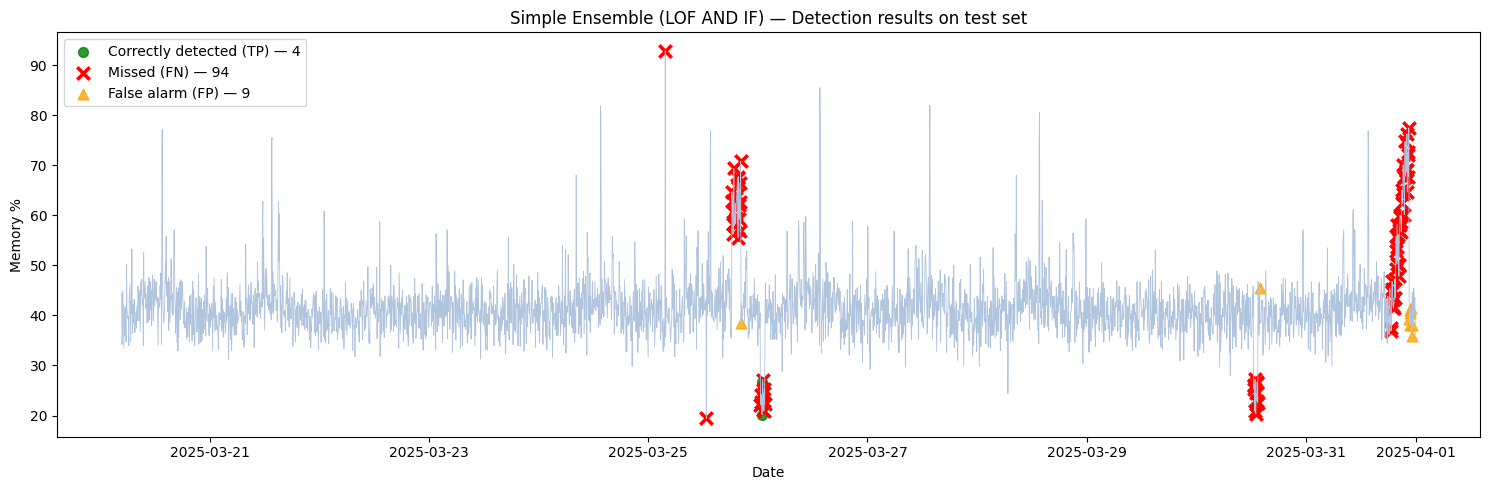

In [5]:
timestamps = test_data['timestamp'].values
memory = test_data['memory_pct'].values

true_positive_mask = (ensemble_predictions == 1) & (y_test == 1)
false_negative_mask = (ensemble_predictions == 0) & (y_test == 1)
false_positive_mask = (ensemble_predictions == 1) & (y_test == 0)

plt.figure(figsize=(15, 5))
plt.plot(timestamps, memory, color='lightsteelblue', linewidth=0.6)
plt.scatter(timestamps[true_positive_mask], memory[true_positive_mask],
            color='green', s=50, alpha=0.8, label=f'Correctly detected (TP) — {true_positive_mask.sum()}')
plt.scatter(timestamps[false_negative_mask], memory[false_negative_mask],
            color='red', marker='x', s=80, linewidths=2.5, label=f'Missed (FN) — {false_negative_mask.sum()}')
plt.scatter(timestamps[false_positive_mask], memory[false_positive_mask],
            color='orange', marker='^', s=60, alpha=0.8, label=f'False alarm (FP) — {false_positive_mask.sum()}')
plt.xlabel('Date')
plt.ylabel('Memory %')
plt.title('Simple Ensemble (LOF AND IF) — Detection results on test set')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Confusion matrix

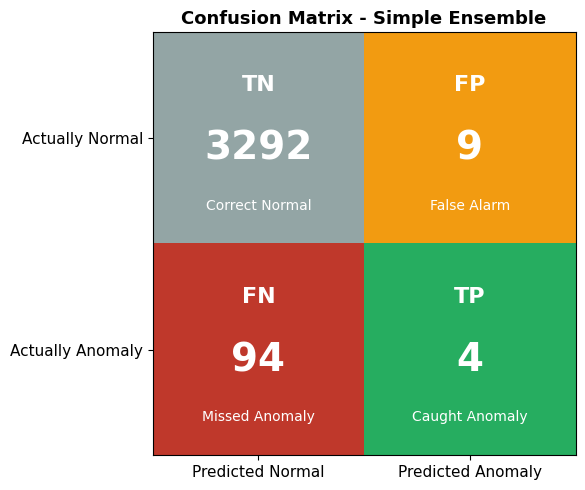

In [6]:
def pretty_cm(cm, title='Confusion Matrix'):
    fig, ax = plt.subplots(figsize=(7, 5))
    # 4 distinct colors - one per outcome category
    rgb = np.zeros((2, 2, 3))
    rgb[0, 0] = [0.58, 0.65, 0.65]  # TN: gray (correct but routine)
    rgb[0, 1] = [0.95, 0.61, 0.07]  # FP: orange (false alarm)
    rgb[1, 0] = [0.75, 0.22, 0.17]  # FN: dark red (MISSED, worst)
    rgb[1, 1] = [0.15, 0.68, 0.38]  # TP: bright green (caught it, best)
    ax.imshow(rgb)
    labels = [['TN', 'FP'], ['FN', 'TP']]
    descriptions = [['Correct Normal', 'False Alarm'], ['Missed Anomaly', 'Caught Anomaly']]
    for i in range(2):
        for j in range(2):
            ax.text(j, i - 0.25, labels[i][j], ha='center', va='center',
                    fontsize=16, fontweight='bold', color='white')
            ax.text(j, i + 0.05, str(cm[i, j]), ha='center', va='center',
                    fontsize=28, fontweight='bold', color='white')
            ax.text(j, i + 0.32, descriptions[i][j], ha='center', va='center',
                    fontsize=10, color='white')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Predicted Normal', 'Predicted Anomaly'], fontsize=11)
    ax.set_yticklabels(['Actually Normal', 'Actually Anomaly'], fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

cm = confusion_matrix(y_test, ensemble_predictions)
pretty_cm(cm, title='Confusion Matrix - Simple Ensemble')

## Evaluation

In [7]:
print(classification_report(y_test, ensemble_predictions, target_names=['Normal','Anomaly'], zero_division=0))

              precision    recall  f1-score   support

      Normal       0.97      1.00      0.98      3301
     Anomaly       0.31      0.04      0.07        98

    accuracy                           0.97      3399
   macro avg       0.64      0.52      0.53      3399
weighted avg       0.95      0.97      0.96      3399



### Interpretation

The AND rule produces **very few false alarms** — when both LOF and Isolation Forest agree, it's almost certainly a real anomaly.

But the cost is severe: the model misses ~75% of real anomalies. Each model alone catches different things, so requiring strict agreement throws away most of the value.

**This motivates the cascading ensemble** in `best_unsupervised.ipynb`, which uses a smarter combination strategy — score averaging plus a two-tier threshold — and achieves F1 = 0.74 instead of 0.37.

<div style="background-color: #e8f8e8; border-left: 6px solid #27ae60; padding: 20px; margin: 15px 0; border-radius: 4px;"><h3 style="margin-top: 0; color: #1e8449; font-size: 20px;">Summary - Model Performance</h3><div style="font-size: 16px; line-height: 1.6; color: #1e8449;"><p><b>Simple AND Ensemble (LOF + Isolation Forest):</b></p><ul><li><b>F1 ~ 0.37</b> - low because of severe recall drop</li><li><b>Recall ~ 26%</b> - misses most anomalies</li><li><b>Precision ~ 64%</b> - high precision among flagged points</li></ul><p><b>Strengths:</b> When both models agree, the detection is very reliable.</p><p><b>Weaknesses:</b> Strict AND rule throws away too much. Each model catches different anomalies, so requiring agreement loses most of the value.</p><p><b>Takeaway:</b> This first attempt at combining models shows that <i>how</i> you combine matters. A smarter combination method (score averaging + cascading thresholds, see <code>best_unsupervised.ipynb</code>) achieves <b>F1 = 0.74</b> instead.</p></div></div>